# Feature Engineering Pipeline — Network Traffic Dataset

**Goal:** Transform the cleaned network-flow dataset into pre-model-ready features.  
**Input:** `../data/processed/cleaned_traffic_data.csv`  
**Output:** `../data/processed/traffic_features_engineered.csv`

**Note:** `StandardScaler` is intentionally excluded from this notebook.  
Scaling must be fit on the training set only; it is applied after the train/val/test split in `03_data_splitting.ipynb` to prevent data leakage.

---

| Step | Action | Rationale |
|------|--------|-----------|
| 1 | Imports & configuration | Libraries and path constants |
| 2 | Data loading & target column detection | Load cleaned dataset |
| 3 | `has_active_idle` binary flag | Preserve structural information before log transform |
| 4 | Feature engineering (13 derived columns) | Strengthen traffic-type separability |
| 5 | `log1p` normalisation | Compress heavy-tailed distributions |
| 6 | Data cleaning | Negative, inf, NaN and duplicate checks |
| 7 | One-hot encoding | Encode remaining categorical columns (target excluded) |
| 8 | Export | Persist pre-model-ready dataset |
| 9 | Validation | Visualise derived feature distributions |

---

## 1. Imports & Configuration

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"         : 11,
})

DATA_PATH   = "../data/processed/cleaned_traffic_data.csv"
OUTPUT_PATH = "../data/processed/traffic_features_engineered.csv"

print("Libraries loaded.")

Libraries loaded.


---

## 2. Data Loading & Target Column Detection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Input shape : {df.shape[0]:,} rows x {df.shape[1]} columns")

target_column = None
for col in df.columns:
    if col.lower() in ["traffic_type", "target", "label", "class"]:
        target_column = col
        break

if target_column is None:
    target_column = df.columns[-1]
    print(f"No named target column found. Using last column: '{target_column}'")
else:
    print(f"Target column detected: '{target_column}'")

print(f"\nClass distribution:")
print(df[target_column].value_counts())

Input shape : 40,987 rows x 11 columns
Target column detected: 'traffic_type'

Class distribution:
traffic_type
VPN-BROWSING     7317
BROWSING         6459
VOIP             6344
VPN-VOIP         5335
VPN-FT           3336
VPN-CHAT         2178
FT               2146
CHAT             2127
P2P              1950
VPN-STREAMING     835
MAIL              828
VPN-P2P           792
STREAMING         749
VPN-MAIL          591
Name: count, dtype: int64


---

## 3. `has_active_idle` Binary Flag

A value of `-1` in `min_active` or `min_idle` indicates that no active / idle window was observed for that flow.  
This structural difference would be lost after the log transform, so it is captured as a binary flag first.

```
has_active_idle = 0  ->  no window observed  (min_active == -1  OR  min_idle == -1)
has_active_idle = 1  ->  window observed
```

In [3]:
_required = {"min_active", "min_idle"}

if _required.issubset(df.columns):
    df["has_active_idle"] = np.where(
        (df["min_active"] == -1) | (df["min_idle"] == -1), 0, 1
    )
    n0 = (df["has_active_idle"] == 0).sum()
    n1 = (df["has_active_idle"] == 1).sum()
    print(f"has_active_idle  ->  0 (no window): {n0:,}  |  1 (window present): {n1:,}")
else:
    missing = _required - set(df.columns)
    print(f"Warning: columns not found, flag skipped: {missing}")

---

## 4. Feature Engineering

Thirteen derived features are added to strengthen traffic-type separability.

| New Column | Formula | What It Measures |
|---|---|---|
| `bytes_per_pkt` | `flowBytesPerSecond / (flowPktsPerSecond + e)` | Payload per packet |
| `iat_cv` | `std_flowiat / (mean_flowiat + 1)` | Packet-arrival irregularity |
| `symmetry_index` | `(total_fiat - total_biat) / (total_fiat + total_biat + 1)` | Traffic directionality |
| `active_idle_ratio` | `mean_active / (mean_idle + 1)` | Connection intensity |
| `log_duration` | `log1p(duration)` | Compressed flow duration |
| `fiat_biat_ratio` | `total_fiat / (total_biat + 1)` | Forward vs backward volume balance |
| `fiat_range` | `max_fiat - min_fiat` | Forward IAT spread |
| `biat_range` | `max_biat - min_biat` | Backward IAT spread |
| `iat_range` | `max_flowiat - min_flowiat` | Overall IAT spread |
| `active_ratio` | `mean_active / (duration + 1)` | Active proportion |
| `idle_ratio` | `mean_idle / (duration + 1)` | Idle proportion |
| `active_cv` | `std_active / (mean_active + 1)` | Active variability |
| `idle_cv` | `std_idle / (mean_idle + 1)` | Idle variability |

In [4]:
_fe_log = []

def _add_feature(name, condition_cols, formula_fn):
    if set(condition_cols).issubset(df.columns):
        df[name] = formula_fn()
        _fe_log.append(f"OK    {name}")
    else:
        _fe_log.append(f"SKIP  {name}  --  missing columns: {set(condition_cols) - set(df.columns)}")

_add_feature(
    "bytes_per_pkt",
    ["flowBytesPerSecond", "flowPktsPerSecond"],
    lambda: df["flowBytesPerSecond"] / (df["flowPktsPerSecond"] + 1e-6),
)
_add_feature(
    "iat_cv",
    ["std_flowiat", "mean_flowiat"],
    lambda: df["std_flowiat"] / (df["mean_flowiat"] + 1),
)
_add_feature(
    "symmetry_index",
    ["total_fiat", "total_biat"],
    lambda: (df["total_fiat"] - df["total_biat"]) / (df["total_fiat"] + df["total_biat"] + 1),
)
_add_feature(
    "active_idle_ratio",
    ["mean_active", "mean_idle"],
    lambda: df["mean_active"] / (df["mean_idle"] + 1),
)
_add_feature(
    "log_duration",
    ["duration"],
    lambda: np.log1p(df["duration"]),
)
_add_feature(
    "fiat_biat_ratio",
    ["total_fiat", "total_biat"],
    lambda: df["total_fiat"] / (df["total_biat"] + 1),
)
_add_feature(
    "fiat_range",
    ["max_fiat", "min_fiat"],
    lambda: np.maximum(df["max_fiat"] - df["min_fiat"], 0),
)
_add_feature(
    "biat_range",
    ["max_biat", "min_biat"],
    lambda: np.maximum(df["max_biat"] - df["min_biat"], 0),
)
_add_feature(
    "iat_range",
    ["max_flowiat", "min_flowiat"],
    lambda: np.maximum(df["max_flowiat"] - df["min_flowiat"], 0),
)
_add_feature(
    "active_ratio",
    ["mean_active", "duration"],
    lambda: df["mean_active"] / (df["duration"] + 1),
)
_add_feature(
    "idle_ratio",
    ["mean_idle", "duration"],
    lambda: df["mean_idle"] / (df["duration"] + 1),
)
_add_feature(
    "active_cv",
    ["std_active", "mean_active"],
    lambda: df["std_active"] / (df["mean_active"] + 1),
)
_add_feature(
    "idle_cv",
    ["std_idle", "mean_idle"],
    lambda: df["std_idle"] / (df["mean_idle"] + 1),
)

print("\n".join(_fe_log))
print(f"\nNew shape: {df.shape}")

OK    bytes_per_pkt
SKIP  iat_cv  --  missing columns: {'std_flowiat', 'mean_flowiat'}
SKIP  symmetry_index  --  missing columns: {'total_fiat'}
SKIP  active_idle_ratio  --  missing columns: {'mean_idle', 'mean_active'}
OK    log_duration
SKIP  fiat_biat_ratio  --  missing columns: {'total_fiat'}
OK    fiat_range
OK    biat_range
SKIP  iat_range  --  missing columns: {'max_flowiat'}
SKIP  active_ratio  --  missing columns: {'mean_active'}
SKIP  idle_ratio  --  missing columns: {'mean_idle'}
SKIP  active_cv  --  missing columns: {'mean_active'}
SKIP  idle_cv  --  missing columns: {'std_idle', 'mean_idle'}

New shape: (40987, 15)


---

## 5. `log1p` Normalisation

Columns like `flowBytesPerSecond` span 0 to 600M, which can cause gradient explosion or vanishing in deep networks.  
`log1p(x) = ln(1 + x)` compresses the distribution and safely returns `0` for `x = 0`.  
This step runs before `StandardScaler` (applied in notebook 03) so the scaler operates on an already compressed range.

**Excluded from transform:** `target_column` and `has_active_idle`.

In [5]:
sentinel_cols = [c for c in ["min_active", "max_active", "min_idle", "max_idle"] if c in df.columns]
if sentinel_cols:
    df[sentinel_cols] = df[sentinel_cols].replace(-1, 0)
    print(f"Sentinel -1 replaced with 0 in: {sentinel_cols}")

_exclude = {target_column, "has_active_idle", "symmetry_index"}
_numeric = [c for c in df.select_dtypes(include=[np.number]).columns if c not in _exclude]

df[_numeric] = np.log1p(df[_numeric])

print(f"Columns transformed with log1p : {len(_numeric)}")
print(f"Excluded                       : {_exclude & set(df.columns)}")

Columns transformed with log1p : 14
Excluded                       : {'traffic_type'}


---

## 6. Data Cleaning

Four quality-assurance steps are applied:

1. **Negative values** -> clipped to `0`
2. **Infinity values** (`+/-inf`) -> converted to `NaN`
3. **NaN rows** -> dropped
4. **Duplicate rows** -> dropped

In [6]:
_all_numeric = df.select_dtypes(include=[np.number]).columns
_non_negative = [c for c in _all_numeric if c != "symmetry_index"]

# 1. Negative value correction
_neg_before = (df[_non_negative] < 0).sum().sum() if _non_negative else 0
if _non_negative:
    df[_non_negative] = df[_non_negative].clip(lower=0)
print(f"Clipped negative values : {_neg_before:,}")

# 2-3. Inf -> NaN, then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
_rows_before_nan = df.shape[0]
df.dropna(inplace=True)
print(f"Rows removed (NaN)      : {_rows_before_nan - df.shape[0]:,}")

# 4. Duplicate removal
_rows_before_dup = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Rows removed (dup)      : {_rows_before_dup - df.shape[0]:,}")

print(f"\nClean dataset shape: {df.shape[0]:,} x {df.shape[1]}")

Clipped negative values : 0
Rows removed (NaN)      : 0
Rows removed (dup)      : 2

Clean dataset shape: 40,985 x 15


---

## 7. One-Hot Encoding

Categorical columns are one-hot encoded via `get_dummies` (`drop_first=True` avoids the dummy-variable trap).

**Note:** The target column is intentionally excluded here.  
Integer label encoding is applied after the split in `03_data_splitting.ipynb`.

In [7]:
# Exclude the target column from one-hot encoding
_cat_cols = [
    c for c in df.select_dtypes(include=["object", "category"]).columns
    if c != target_column
]

if _cat_cols:
    df = pd.get_dummies(df, columns=_cat_cols, drop_first=True)
    print(f"Encoded categorical columns : {_cat_cols}")
else:
    print("No categorical columns found to encode.")

print(f"Shape after encoding: {df.shape}")

No categorical columns found to encode.
Shape after encoding: (40985, 15)


---

## 8. Export

In [8]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved to    : '{OUTPUT_PATH}'")
print(f"Final shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nFeature columns ({df.shape[1] - 1}):")
print([c for c in df.columns if c != target_column])

Saved to    : '../data/processed/traffic_features_engineered.csv'
Final shape : 40,985 rows x 15 columns

Feature columns (14):
['duration', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'std_active', 'bytes_per_pkt', 'log_duration', 'fiat_range', 'biat_range']


---

## 9. Validation — Derived Feature Distributions

Visualising the derived features to confirm they carry discriminative signal across traffic classes.

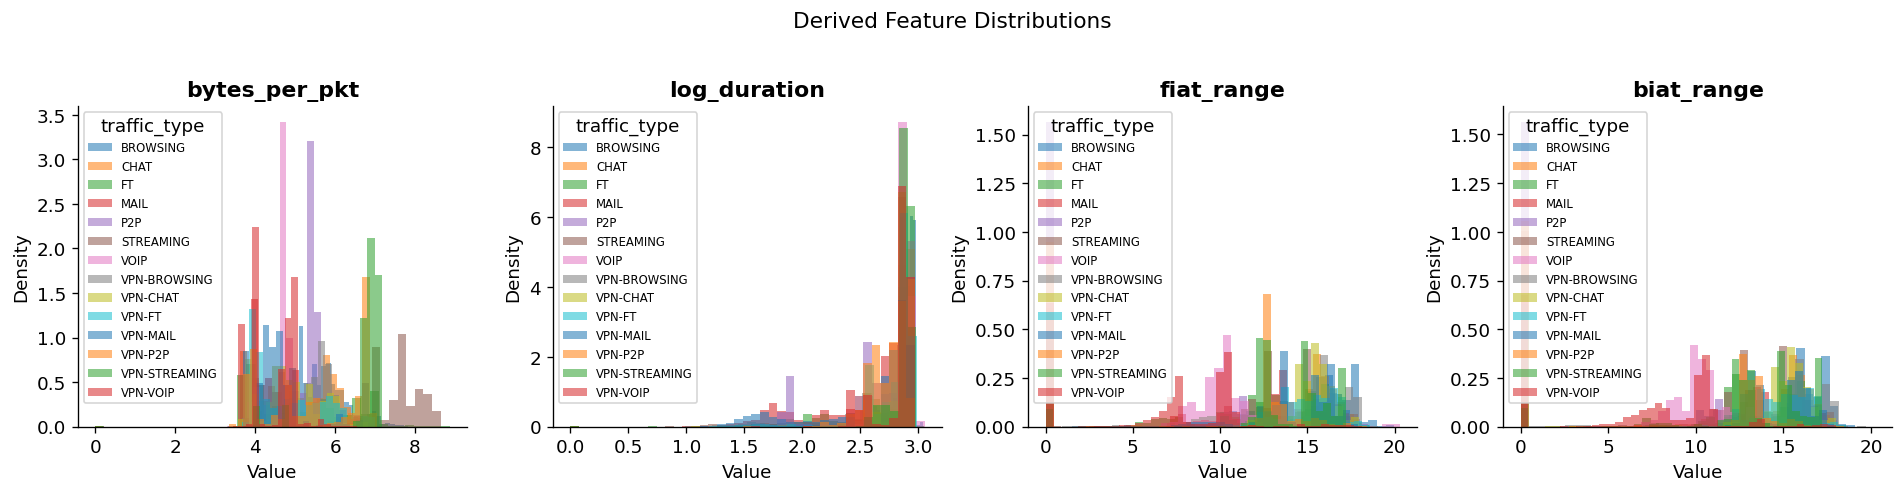

In [9]:
_new_features = [f for f in ["bytes_per_pkt", "iat_cv", "symmetry_index",
                               "active_idle_ratio", "log_duration", "fiat_biat_ratio",
                               "fiat_range", "biat_range", "iat_range", "active_ratio",
                               "idle_ratio", "active_cv", "idle_cv"]
                 if f in df.columns]

_target_in_df = target_column in df.columns

if _new_features:
    fig, axes = plt.subplots(1, len(_new_features), figsize=(4 * len(_new_features), 4))
    if len(_new_features) == 1:
        axes = [axes]

    for ax, feat in zip(axes, _new_features):
        if _target_in_df and df[target_column].nunique() <= 15:
            for label in df[target_column].unique():
                subset = df[df[target_column] == label][feat]
                ax.hist(subset, bins=40, alpha=0.55, label=str(label), density=True)
            ax.legend(fontsize=7, title=target_column)
        else:
            ax.hist(df[feat], bins=40, color="steelblue", alpha=0.8)
        ax.set_title(feat, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")

    plt.suptitle("Derived Feature Distributions", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No derived features found to visualise.")